# Hands-on Robotics -- Plotting Exercise

# Exercise 1: timelines

## STEP 1: let's start from basic import

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## STEP 2: load data

In [5]:
df = pd.read_excel('HoR_rawdata2plot.xlsx', sheet_name='EX1')
print(df)

    Pressure        CR1        CR2        CR3        CR4        CR5  \
0          0   6.666667  10.000000   6.666667   5.000000  10.000000   
1          2   8.333333  11.000000   8.333333   6.666667  12.333333   
2          4   9.666667  11.666667   9.666667   7.000000  13.000000   
3          6  11.666667  12.666667  10.666667   8.333333  17.333333   
4          8  14.333333  15.000000  11.666667   9.000000  17.000000   
5         10  18.333333  17.666667  16.000000  10.666667  20.000000   
6         12  23.333333  22.666667  18.000000  15.000000  22.333333   
7         15  26.666667  28.000000  22.000000  18.333333  26.666667   
8         17  31.666667  29.000000  24.666667  20.000000  28.333333   
9         20  32.333333  32.666667  29.000000  25.666667  30.666667   
10        22  33.333333  34.333333  30.000000  26.666667  31.666667   
11        25  34.000000  35.000000  33.000000  30.333333  33.666667   

          CR6        CR7        CR8        CR9       CR10  
0    6.666667  1

## STEP 3: the bare minimum

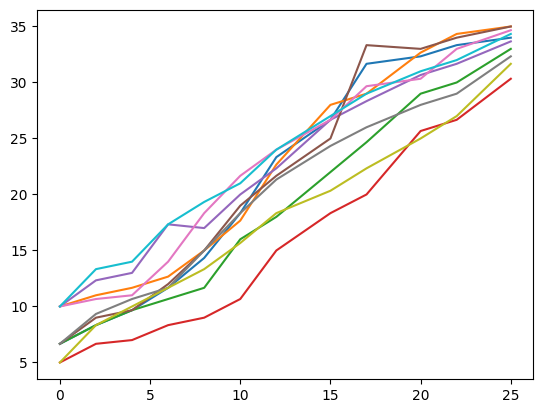

In [6]:
fig, ax = plt.subplots()
for i in range(1, 11):
    ax.plot(df['Pressure'], df[f'CR{i}'])
plt.show()

## STEP 3: small improvements

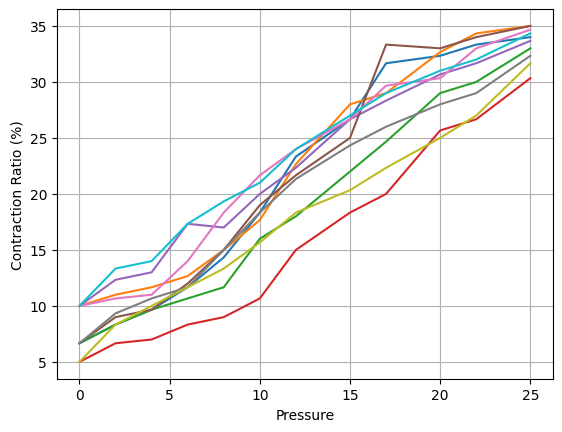

In [7]:
fig, ax = plt.subplots()
for i in range(1, 11):
    ax.plot(df['Pressure'], df[f'CR{i}'])
ax.set_xlabel('Pressure')
ax.set_ylabel('Contraction Ratio (%)')
ax.grid()
plt.show()

## STEP 4: better visualization of trends

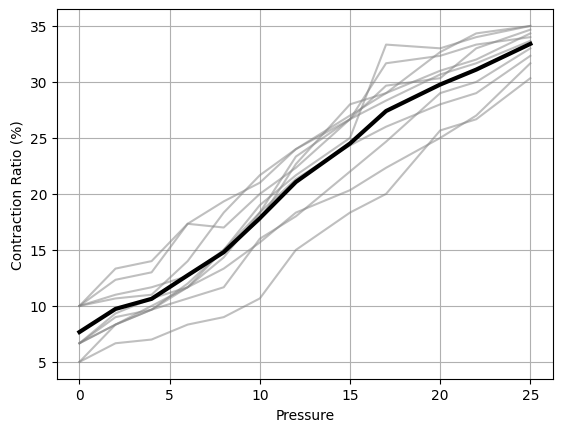

In [8]:
fig, ax = plt.subplots()
for i in range(1, 11):
    ax.plot(df['Pressure'], df[f'CR{i}'], alpha=0.5, color='gray')

cols_CR = [f'CR{i}' for i in range(1, 11)]
df['CR_mean'] = df[cols_CR].mean(axis=1)
ax.plot(df['Pressure'], df['CR_mean'], linewidth=3, color='black')

ax.set_xlabel('Pressure')
ax.set_ylabel('Contraction Ratio (%)')
ax.grid()
plt.show()

## STEP 5: from raw to STD/SE

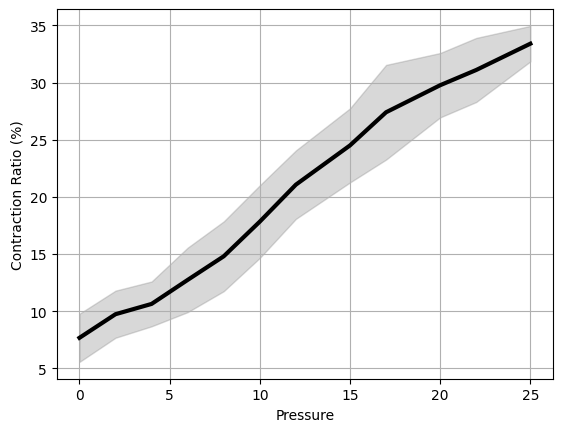

In [9]:
fig, ax = plt.subplots()

cols_CR = [f'CR{i}' for i in range(1, 11)]
df['CR_mean'] = df[cols_CR].mean(axis=1)
df['CR_std'] = df[cols_CR].std(axis=1)  # /np.sqrt(len(cols_CR))

ax.plot(df['Pressure'], df['CR_mean'], linewidth=3, color='black')
ax.fill_between(df['Pressure'], df['CR_mean']-df['CR_std'], df['CR_mean']+df['CR_std'], color='gray', alpha=0.3)

ax.set_xlabel('Pressure')
ax.set_ylabel('Contraction Ratio (%)')
ax.grid()
plt.show()

## STEP 6: top-notch quality

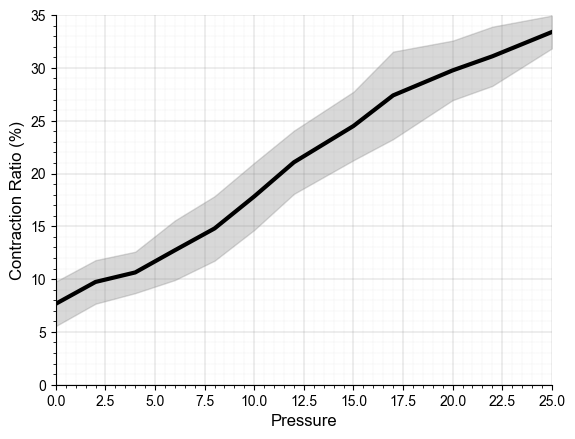

In [10]:
fig, ax = plt.subplots()
font = {'fontname':'Arial'}

cols_CR = [f'CR{i}' for i in range(1, 11)]
df['CR_mean'] = df[cols_CR].mean(axis=1)
df['CR_std'] = df[cols_CR].std(axis=1)  # /np.sqrt(len(cols_CR))

ax.plot(df['Pressure'], df['CR_mean'], linewidth=3, color='black')
ax.fill_between(df['Pressure'], df['CR_mean']-df['CR_std'], df['CR_mean']+df['CR_std'], color='gray', alpha=0.3)

ax.set_xlabel('Pressure',**font, fontsize=12)
ax.set_ylabel('Contraction Ratio (%)',**font, fontsize=12)
ax.grid()

plt.xlim(0, 25)
plt.xticks(np.arange(0, 25.1, step=2.5), **font)
plt.ylim(0, 35)
plt.yticks(np.arange(0, 35.1, step=5), **font)

ax.minorticks_on()
ax.grid(which='minor', linestyle=':', linewidth='0.1', color='gray')
ax.grid(which='major', linestyle='-', linewidth='0.2', color='gray')
ax.spines['top']. set_visible(False)
ax.spines['right']. set_visible(False)


plt.show()

# Exercise 2: plotting scatter data

## STEP 1: load data

In [11]:
df = pd.read_excel('HoR_rawdata2plot.xlsx', sheet_name='EX2')
print(df)

   SCI_ID  ROM_OFF  ROM_ON  BICEPS_OFF  PRONATOR_OFF  BICEPS_ON  PRONATOR_ON
0       1    77.17   88.38      8.0900        8.6800       1.52         5.26
1       2   146.47  140.59     12.2788        3.3189       4.85         3.05
2       3    86.16  103.62     10.7700        3.6200       6.34         3.90
3       4     0.53   54.58      4.6900        2.1300       4.67         2.18
4       5    23.29   51.88         NaN        8.8400        NaN         9.40
5       6    70.33   96.83      5.2400        4.7600       2.37         3.44
6       7   117.68  136.78      3.1100        9.0400       2.70        14.29
7       8   101.76  118.18      2.5600        1.1200       1.40         2.24
8       9    14.55   27.34     21.5200       16.7700      11.83        11.11
9      10    77.55  124.20      1.9600        5.6200       2.65         3.83


## STEP 2: bare minimum

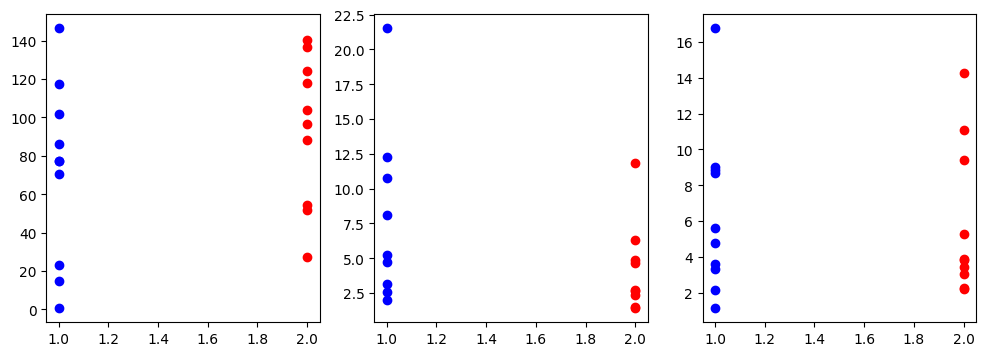

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

x_vec = np.ones(10)

ax[0].scatter(x_vec*1, df['ROM_OFF'], color='blue')
ax[0].scatter(x_vec*2, df['ROM_ON'], color='red')

ax[1].scatter(x_vec*1, df['BICEPS_OFF'], color='blue')
ax[1].scatter(x_vec*2, df['BICEPS_ON'], color='red')

ax[2].scatter(x_vec*1, df['PRONATOR_OFF'], color='blue')
ax[2].scatter(x_vec*2, df['PRONATOR_ON'], color='red')

plt.show()

## STEP 3: small improvements

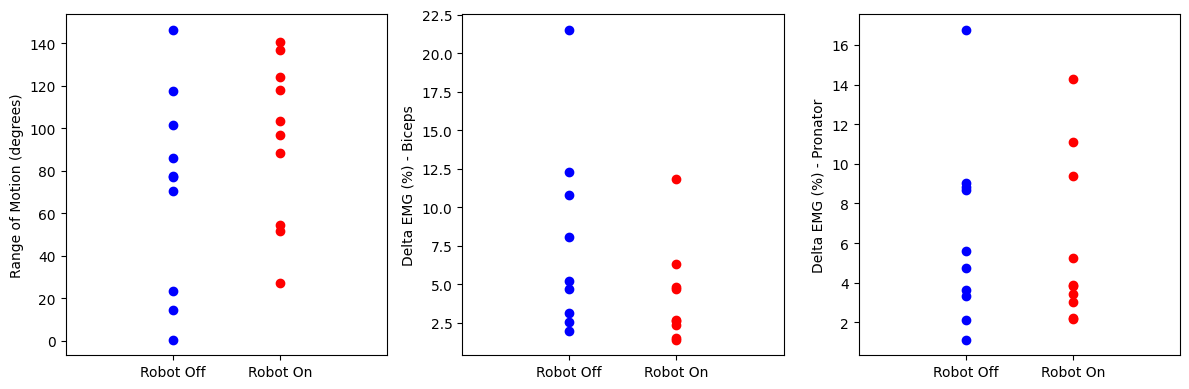

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

x_vec = np.ones(10)

ax[0].scatter(x_vec*1, df['ROM_OFF'], color='blue')
ax[0].scatter(x_vec*2, df['ROM_ON'],  color='red')
ax[0].set_xlim(0, 3)
ax[0].set_xticks([1, 2])
ax[0].set_xticklabels(['Robot Off', 'Robot On'])
ax[0].set_ylabel('Range of Motion (degrees)')

ax[1].scatter(x_vec*1, df['BICEPS_OFF'], color='blue')
ax[1].scatter(x_vec*2, df['BICEPS_ON'],  color='red')
ax[1].set_xlim(0, 3)
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(['Robot Off', 'Robot On'])
ax[1].set_ylabel('Delta EMG (%) - Biceps')

ax[2].scatter(x_vec*1, df['PRONATOR_OFF'], color='blue')
ax[2].scatter(x_vec*2, df['PRONATOR_ON'],  color='red')
ax[2].set_xlim(0, 3)
ax[2].set_xticks([1, 2])
ax[2].set_xticklabels(['Robot Off', 'Robot On'])
ax[2].set_ylabel('Delta EMG (%) - Pronator')

plt.tight_layout()
plt.show()


## STEP 4: MVP (minimum viable product)

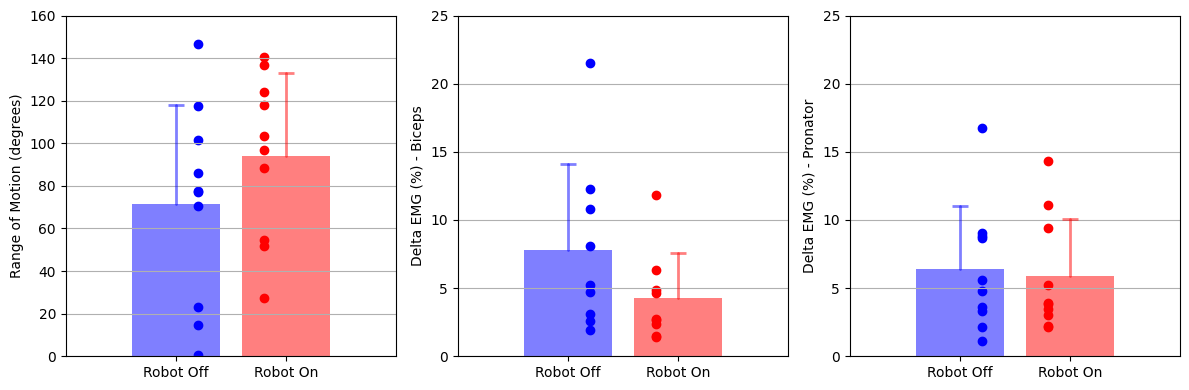

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

color_off = 'blue'
color_on = 'red'
x_vec = np.ones(10)

ax[0].scatter(x_vec*1.2, df['ROM_OFF'], color=color_off)
ax[0].scatter(x_vec*1.8, df['ROM_ON'],  color=color_on)
ax[0].set_xlim(0, 3)
ax[0].set_xticks([1, 2])
ax[0].set_xticklabels(['Robot Off', 'Robot On'])
ax[0].set_ylabel('Range of Motion (degrees)')

mean_ROM_OFF = df['ROM_OFF'].mean()
mean_ROM_ON = df['ROM_ON'].mean()
std_ROM_OFF = df['ROM_OFF'].std()
std_ROM_ON = df['ROM_ON'].std()
ax[0].bar([1, 2], [mean_ROM_OFF, mean_ROM_ON], color=[color_off, color_on], alpha= 0.5)
# ax[0].errorbar([1, 2], [mean_ROM_OFF, mean_ROM_ON], yerr=[std_ROM_OFF, std_ROM_ON], fmt='none', capsize=5, ecolor=[color_off, color_on])  # this is not working cause of color argument
for x, y, err, c in zip(
    [1, 2], 
    [mean_ROM_OFF, mean_ROM_ON], 
    [std_ROM_OFF, std_ROM_ON], 
    [color_off, color_on]
):
    ax[0].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5) # workaround to have bars only in the positive direction
    ax[0].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5) # workaround to have bars only in the positive direction


ax[1].scatter(x_vec*1.2, df['BICEPS_OFF'], color=color_off)
ax[1].scatter(x_vec*1.8, df['BICEPS_ON'],  color=color_on)
ax[1].set_xlim(0, 3)
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(['Robot Off', 'Robot On'])
ax[1].set_ylabel('Delta EMG (%) - Biceps')

mean_BICEPS_OFF = df['BICEPS_OFF'].mean()
mean_BICEPS_ON = df['BICEPS_ON'].mean()
std_BICEPS_OFF = df['BICEPS_OFF'].std()
std_BICEPS_ON = df['BICEPS_ON'].std()
ax[1].bar([1, 2], [mean_BICEPS_OFF, mean_BICEPS_ON], color=[color_off, color_on], alpha= 0.5)
for x, y, err, c in zip(
    [1, 2], 
    [mean_BICEPS_OFF, mean_BICEPS_ON], 
    [std_BICEPS_OFF, std_BICEPS_ON], 
    [color_off, color_on]
):
    ax[1].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5) # workaround to have bars only in the positive direction
    ax[1].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5) # workaround to have bars only in the positive direction

ax[2].scatter(x_vec*1.2, df['PRONATOR_OFF'], color=color_off)
ax[2].scatter(x_vec*1.8, df['PRONATOR_ON'],  color=color_on)
ax[2].set_xlim(0, 3)
ax[2].set_xticks([1, 2])
ax[2].set_xticklabels(['Robot Off', 'Robot On'])
ax[2].set_ylabel('Delta EMG (%) - Pronator')

mean_PRONATOR_OFF = df['PRONATOR_OFF'].mean()
mean_PRONATOR_ON = df['PRONATOR_ON'].mean()
std_PRONATOR_OFF = df['PRONATOR_OFF'].std()
std_PRONATOR_ON = df['PRONATOR_ON'].std()
ax[2].bar([1, 2], [mean_PRONATOR_OFF, mean_PRONATOR_ON], color=[color_off, color_on], alpha= 0.5)
for x, y, err, c in zip(
    [1, 2], 
    [mean_PRONATOR_OFF, mean_PRONATOR_ON], 
    [std_PRONATOR_OFF, std_PRONATOR_ON], 
    [color_off, color_on]
):
    ax[2].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5) # workaround to have bars only in the positive direction
    ax[2].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5) # workaround to have bars only in the positive direction

ax[0].set_ylim(0, 160)
ax[1].set_ylim(0, 25)
ax[2].set_ylim(0, 25)

ax[0].grid(axis='y')
ax[1].grid(axis='y')
ax[2].grid(axis='y')


plt.tight_layout()
plt.show()


## STEP 5: accepted on Nature with minor revision

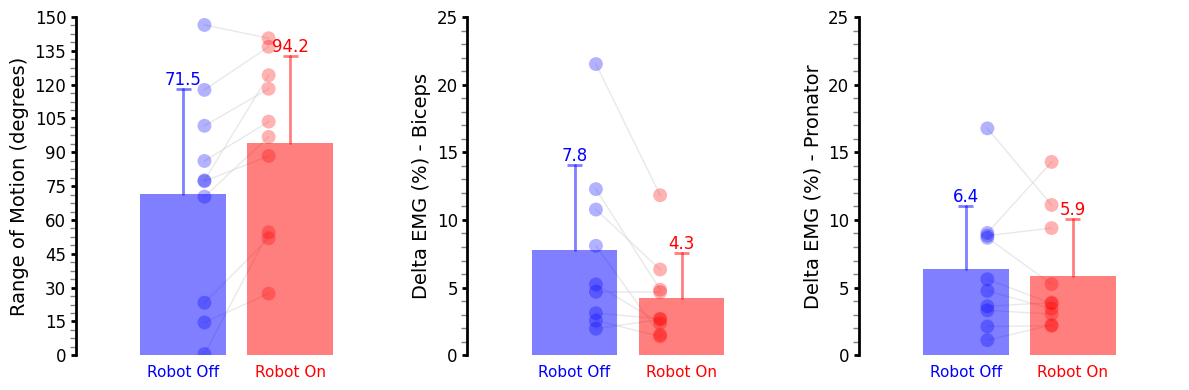

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4)) 

color_off = 'blue'
color_on = 'red'
x_vec = np.ones(10)
scatter_colors = [color_off, color_on]



# === ROM SUBPLOT ===
ax[0].scatter(x_vec*1.2, df['ROM_OFF'], color=color_off, alpha=0.3, s=100, edgecolor='none', zorder=2)
ax[0].scatter(x_vec*1.8, df['ROM_ON'],  color=color_on, alpha=0.3, s=100, edgecolor='none', zorder=2)

# Connect paired scatters with light gray lines
for idx in range(len(df)):
    ax[0].plot([1.2, 1.8], [df.loc[idx, 'ROM_OFF'], df.loc[idx, 'ROM_ON']], 
               color='lightgray', alpha=0.5, linewidth=1, zorder=1)

ax[0].set_xlim(0, 3)
ax[0].set_xticks([1, 2])
ax[0].set_xticklabels(['Robot Off', 'Robot On'], fontsize=11)
for tick_label, color in zip(ax[0].get_xticklabels(), scatter_colors):
    tick_label.set_color(color)

mean_ROM_OFF = df['ROM_OFF'].mean()
mean_ROM_ON = df['ROM_ON'].mean()
std_ROM_OFF = df['ROM_OFF'].std()
std_ROM_ON = df['ROM_ON'].std()
ax[0].bar([1, 2], [mean_ROM_OFF, mean_ROM_ON], color=scatter_colors, alpha=0.5)
for x, y, err, c in zip([1, 2], [mean_ROM_OFF, mean_ROM_ON], [std_ROM_OFF, std_ROM_ON], scatter_colors):
    ax[0].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5)
    ax[0].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5)
    # Colored text on top of bars
    ax[0].text(x, y + err, f"{y:.1f}", ha='center', va='bottom', fontsize=12, color=c)

ax[0].set_ylabel('Range of Motion (degrees)', fontsize=14)
ax[0].tick_params(axis='x', bottom=False)
ax[0].tick_params(axis='y', labelsize=12, width=2)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].spines['left'].set_linewidth(2)
ax[0].set_ylim(0, 150)
ax[0].set_yticks(np.arange(0, 151, 15))
ax[0].minorticks_on()
ax[0].tick_params(axis='y', which='minor', length=4, width=1, color='gray')
ax[0].tick_params(axis='x', which='minor', bottom=False)



# === BICEPS SUBPLOT ===
ax[1].scatter(x_vec*1.2, df['BICEPS_OFF'], color=color_off, alpha=0.3, s=100, edgecolor='none', zorder=2)
ax[1].scatter(x_vec*1.8, df['BICEPS_ON'],  color=color_on, alpha=0.3, s=100, edgecolor='none', zorder=2)

# Connect paired scatters
for idx in range(len(df)):
    ax[1].plot([1.2, 1.8], [df.loc[idx, 'BICEPS_OFF'], df.loc[idx, 'BICEPS_ON']], 
               color='lightgray', alpha=0.5, linewidth=1, zorder=1)

ax[1].set_xlim(0, 3)
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(['Robot Off', 'Robot On'], fontsize=11)
for tick_label, color in zip(ax[1].get_xticklabels(), scatter_colors):
    tick_label.set_color(color)

mean_BICEPS_OFF = df['BICEPS_OFF'].mean()
mean_BICEPS_ON = df['BICEPS_ON'].mean()
std_BICEPS_OFF = df['BICEPS_OFF'].std()
std_BICEPS_ON = df['BICEPS_ON'].std()
ax[1].bar([1, 2], [mean_BICEPS_OFF, mean_BICEPS_ON], color=scatter_colors, alpha=0.5)
for x, y, err, c in zip([1, 2], [mean_BICEPS_OFF, mean_BICEPS_ON], [std_BICEPS_OFF, std_BICEPS_ON], scatter_colors):
    ax[1].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5)
    ax[1].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5)
    ax[1].text(x, y + err, f"{y:.1f}", ha='center', va='bottom', fontsize=12, color=c)

ax[1].set_ylabel('Delta EMG (%) - Biceps', fontsize=14)
ax[1].tick_params(axis='x', bottom=False)
ax[1].tick_params(axis='y', labelsize=12, width=2)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['bottom'].set_visible(False)
ax[1].spines['left'].set_linewidth(2)
ax[1].set_ylim(0, 25)
ax[1].set_yticks(np.arange(0, 26, 5))
ax[1].minorticks_on()
ax[1].tick_params(axis='y', which='minor', length=4, width=1, color='gray')
ax[1].tick_params(axis='x', which='minor', bottom=False)



# === PRONATOR SUBPLOT ===
ax[2].scatter(x_vec*1.2, df['PRONATOR_OFF'], color=color_off, alpha=0.3, s=100, edgecolor='none', zorder=2)
ax[2].scatter(x_vec*1.8, df['PRONATOR_ON'],  color=color_on, alpha=0.3, s=100, edgecolor='none', zorder=2)

# Connect paired scatters
for idx in range(len(df)):
    ax[2].plot([1.2, 1.8], [df.loc[idx, 'PRONATOR_OFF'], df.loc[idx, 'PRONATOR_ON']], 
               color='lightgray', alpha=0.5, linewidth=1, zorder=1)

ax[2].set_xlim(0, 3)
ax[2].set_xticks([1, 2])
ax[2].set_xticklabels(['Robot Off', 'Robot On'], fontsize=11)
for tick_label, color in zip(ax[2].get_xticklabels(), scatter_colors):
    tick_label.set_color(color)

mean_PRONATOR_OFF = df['PRONATOR_OFF'].mean()
mean_PRONATOR_ON = df['PRONATOR_ON'].mean()
std_PRONATOR_OFF = df['PRONATOR_OFF'].std()
std_PRONATOR_ON = df['PRONATOR_ON'].std()
ax[2].bar([1, 2], [mean_PRONATOR_OFF, mean_PRONATOR_ON], color=scatter_colors, alpha=0.5)
for x, y, err, c in zip([1, 2], [mean_PRONATOR_OFF, mean_PRONATOR_ON], [std_PRONATOR_OFF, std_PRONATOR_ON], scatter_colors):
    ax[2].vlines(x, y, y + err, color=c, linewidth=2, capstyle='round', alpha=0.5)
    ax[2].hlines(y + err, x - 0.07, x + 0.07, color=c, linewidth=2, alpha=0.5)
    ax[2].text(x, y + err, f"{y:.1f}", ha='center', va='bottom', fontsize=12, color=c)

ax[2].set_ylabel('Delta EMG (%) - Pronator', fontsize=14)
ax[2].tick_params(axis='x', bottom=False)
ax[2].tick_params(axis='y', labelsize=12, width=2)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['bottom'].set_visible(False)
ax[2].spines['left'].set_linewidth(2)
ax[2].set_ylim(0, 25)
ax[2].set_yticks(np.arange(0, 26, 5))
ax[2].minorticks_on()
ax[2].tick_params(axis='y', which='minor', length=4, width=1, color='gray')
ax[2].tick_params(axis='x', which='minor', bottom=False)

plt.tight_layout()
plt.show()


## STEP 6: the extra mile

![Alt text](./image_exercise2.png)

# EXERCISE 3: >2 data

## STEP 1: load data

In [44]:
df = pd.read_excel('HoR_rawdata2plot.xlsx', sheet_name='EX3')
print(df)

                      Ref    Force   Press    CR      Material
0               This work   400.00  240.00  30.0           TPU
1         Festo (DMSP-10)   630.00  800.00  25.0        Rubber
2         Festo (DMSP-20)  1500.00  600.00  25.0        Rubber
3    Villegas et al. 2012  3000.00  300.00  36.0     Polyester
4       Greer et al. 2017     8.86   10.34  40.0  Polyethylene
5  Diteesawat et al. 2021    56.90   50.00  35.2  Polyethylene
6    Naclerio et al. 2020   120.00  137.00  30.0         Nylon
7        Feng et al. 2023   134.70  150.00  92.9     Nylon-TPU
8       Roche et al. 2015    19.00  145.00  34.9           TPU


## STEP 2: bare minimum

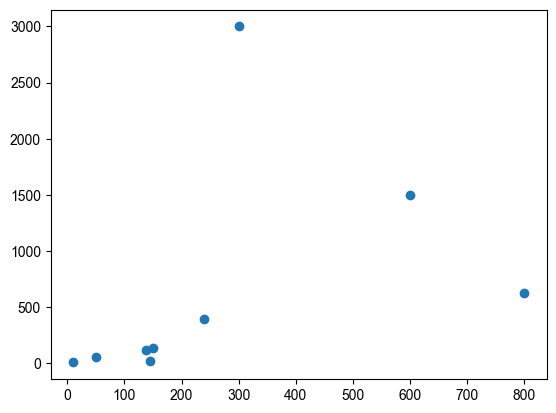

In [80]:
scatter = plt.scatter(data=df, x='Press', y='Force')

plt.show()

## STEP 3: add third dimension

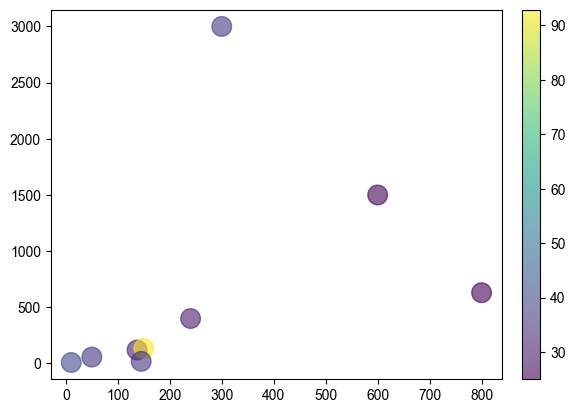

In [81]:
scatter = plt.scatter(data=df, x='Press', y='Force', s=200, zorder=2, alpha=0.6, c=df.CR, cmap='viridis')
plt.colorbar(fraction=0.05, pad=0.04)

plt.show()

## STEP 4: improving readability

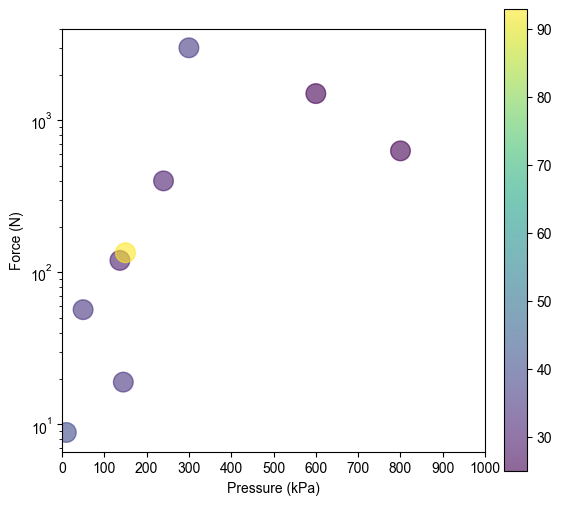

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.rcParams["font.family"] = "Arial"

ax.set_box_aspect(1)
scatter = plt.scatter(data=df, x='Press', y='Force', s=200, zorder=2, alpha=0.6, c=df.CR, cmap='viridis')
plt.colorbar(fraction=0.05, pad=0.04)

ax.set_xlabel('Pressure (kPa)')
ax.set_ylabel('Force (N)')
ax.set_xlim(0,1000)
ax.set_xticks(range(0, 1001, 100))
ax.set_yscale('log')

plt.show()

## STEP 5: it's over

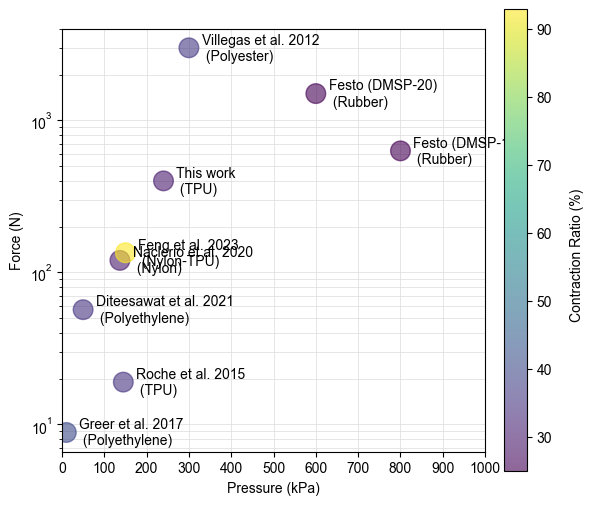

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.rcParams["font.family"] = "Arial"

ax.set_box_aspect(1)
scatter = plt.scatter(data=df, x='Press', y='Force', s=200, zorder=2, alpha=0.6, c=df.CR, cmap='viridis')
plt.colorbar(fraction=0.05, pad=0.04)
plt.tick_params(axis='y', which='minor')
plt.grid(visible=True, which='both', axis='both', linewidth=0.5, color='gainsboro')

ax.set_xlabel('Pressure (kPa)')
ax.set_ylabel('Force (N)')
ax.set_xlim(0,1000)
ax.set_xticks(range(0, 1001, 100))
ax.set_yscale('log')
for i in range(len(df)):
    string = str(df['Ref'][i]) + '\n (' + str(df['Material'][i]) + ')'
    ax.text(df['Press'][i]+30, df['Force'][i], string, fontsize=10, ha='left', va='center')

ax.text(1200, 50, 'Contraction Ratio (%)', rotation=90)

plt.show()